<a href="https://colab.research.google.com/github/SamaTawfik/Credit-Card-Fraud-Detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Libraries


In [65]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score
)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

# Data Ingestion & Merging

In [66]:
print("\n--- Loading Data Files ---")

train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print("Transaction Shape:", train_transaction.shape)
print("Identity Shape:", train_identity.shape)


--- Loading Data Files ---
Transaction Shape: (325675, 394)
Identity Shape: (144233, 41)


# Advanced Feature Engineering

In [67]:
train_transaction.head()
# train_transaction.info()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

# Feature Engineering

In [69]:
#### Merge Datasets ####
print("\n--- Merging Transaction + Identity ---")
has_identity_ids = set(train_identity['TransactionID'])

df = pd.merge(
    train_transaction,
    train_identity,
    on='TransactionID',
    how='left'
)

df['has_identity'] = (
    df['TransactionID']
    .isin(has_identity_ids)
    .astype(int)
)



--- Merging Transaction + Identity ---


In [70]:
# Browser Cleaning
if 'id_31' in df.columns:
    def clean_browser(x):
        if pd.isna(x): return 'Missing'
        x = str(x).lower()
        if 'chrome' in x: return 'chrome'
        if 'safari' in x: return 'safari'
        if 'firefox' in x: return 'firefox'
        if 'edge' in x: return 'edge'
        if 'samsung' in x: return 'samsung'
        if 'opera' in x: return 'opera'
        return 'other'
    df['clean_browser'] = df['id_31'].apply(clean_browser)

# OS Cleaning
if 'id_30' in df.columns:
    def clean_os(x):
        if pd.isna(x): return 'Missing'
        x = str(x).lower()
        if 'windows' in x: return 'windows'
        if 'mac' in x: return 'mac'
        if 'ios' in x: return 'ios'
        if 'android' in x: return 'android'
        if 'linux' in x: return 'linux'
        return 'other'
    df['clean_os'] = df['id_30'].apply(clean_os)

# Log Transform
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

# Time Features
if 'TransactionDT' in df.columns:
    df['Step_Hour'] = (df['TransactionDT'] // 3600) % 24
    df['Is_Night'] = df['Step_Hour'].apply(lambda x: 1 if x in [0, 1, 2, 3, 4, 5] else 0)

# Email Domain Features
for col in ['P_emaildomain', 'R_emaildomain']:
    if col in df.columns:
        df[f'{col}_bin'] = df[col].astype(str).str.split('.').str[0]

# Frequency Encoding
if all(c in df.columns for c in ['card1', 'addr1']):
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    freq = df['card1_addr1'].value_counts()
    df['card1_addr1_freq'] = df['card1_addr1'].map(freq)
    df.drop(columns=['card1_addr1'], inplace=True)





# Data Splitting

In [71]:
# Drop Unnecessary Columns
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
             'P_emaildomain', 'R_emaildomain', 'id_31', 'id_30']
features = [c for c in df.columns if c not in drop_cols]

X = df[features]
y = df['isFraud']


--- Visualizations ---


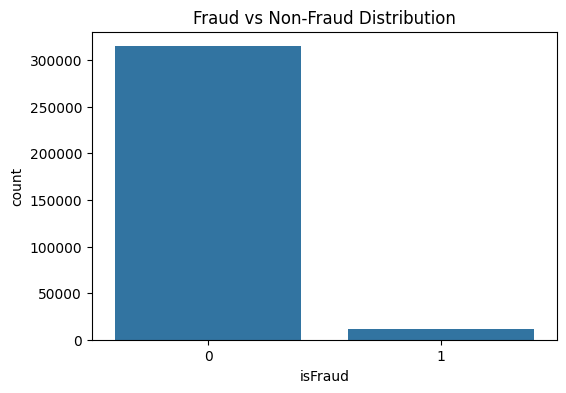

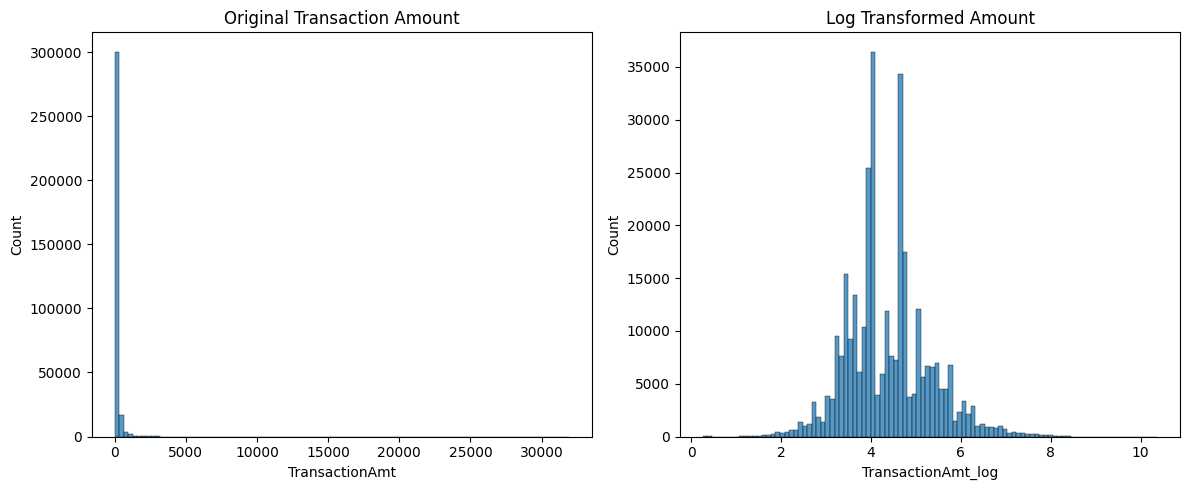

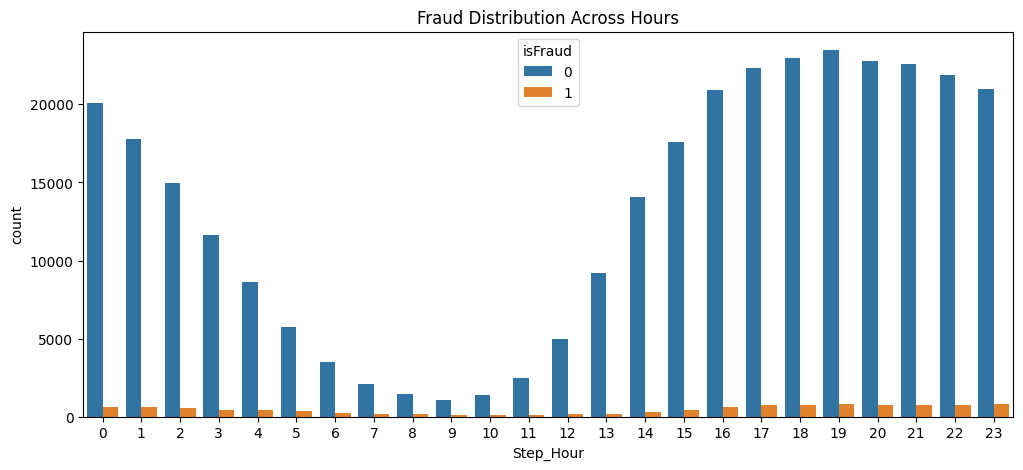

In [72]:
# Visualizations

print("\n--- Visualizations ---")


# Fraud Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()


# Amount Distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['TransactionAmt'], bins=100)
plt.title('Original Transaction Amount')
plt.subplot(1,2,2)
sns.histplot(df['TransactionAmt_log'], bins=100)
plt.title('Log Transformed Amount')
plt.tight_layout()
plt.show()

# Fraud by Hour
plt.figure(figsize=(12,5))
sns.countplot(
    x='Step_Hour',
    hue='isFraud',
    data=df
)
plt.title('Fraud Distribution Across Hours')
plt.show()




In [73]:
#Split Numerical and Categorical

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

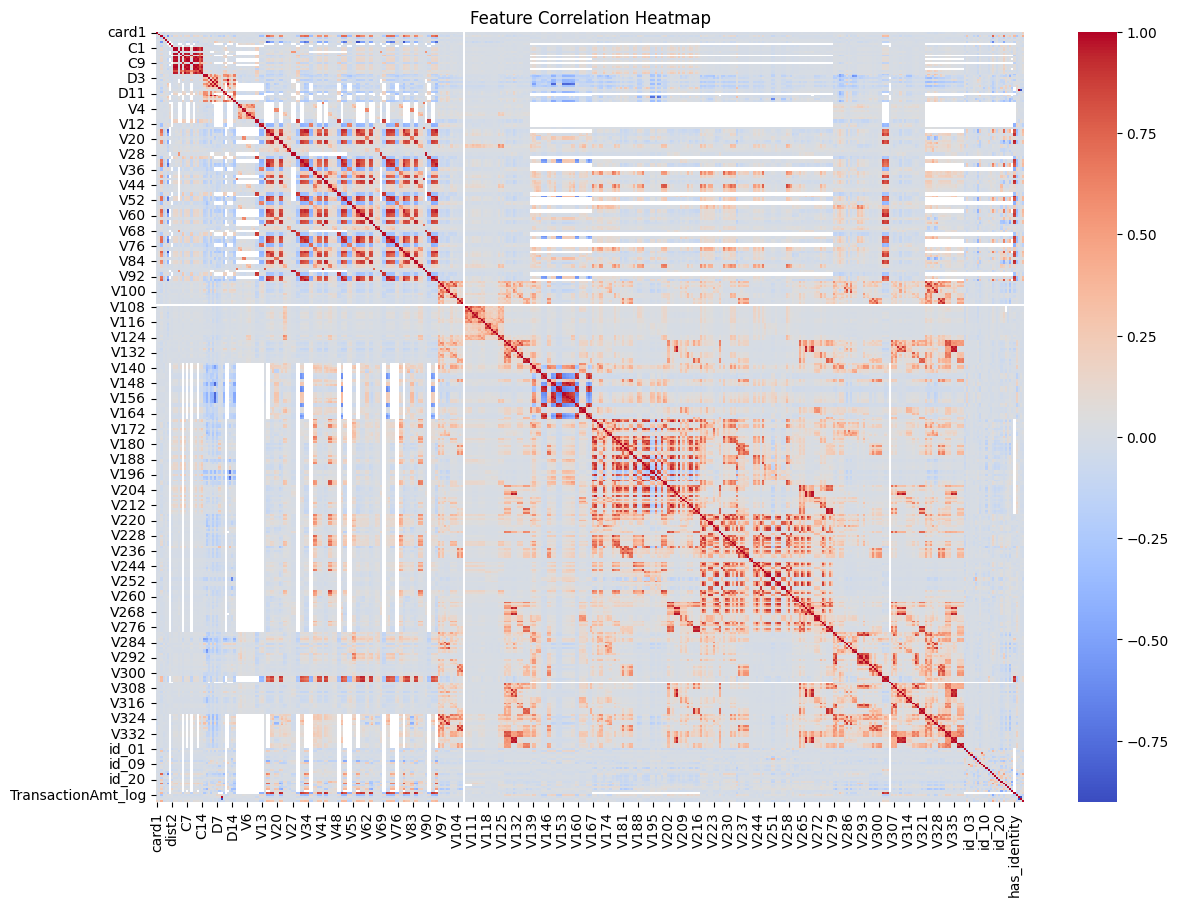

In [74]:
#Correlation Heatmap

plt.figure(figsize=(14,10))
correlation = df[numeric_cols].corr()
sns.heatmap(
    correlation,
    cmap='coolwarm'
)
plt.title('Feature Correlation Heatmap')
plt.show()


In [75]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [76]:
#Handle Imbalanced Data

num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_weight = num_neg / num_pos
print("\nScale Pos Weight:", scale_weight)


Scale Pos Weight: 28.573212258796822


# Preprocessing & Model Training

In [77]:
#Preprocessing

numeric_transformer = 'passthrough'
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [78]:
#XGBoost Model
pipeline = ImbPipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        random_state=42,
        n_jobs=-1,
        missing=np.nan,
        eval_metric='logloss'
    ))
])

#Train Model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['card1', 'card2', 'card3',
                                                   'card5', 'addr1', 'addr2',
                                                   'dist1', 'dist2', 'C1', 'C2',
                                                   'C3', 'C4', 'C5', 'C6', 'C7',
                                                   'C8', 'C9', 'C10', 'C11',
                                                   'C12', 'C13', 'C14', 'D1',
                                                   'D2', 'D3', 'D4', 'D5', 'D6',
                                                   'D7', 'D8', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=-1,
                               num_parallel_tree=None, ...))])

# Feature Importance

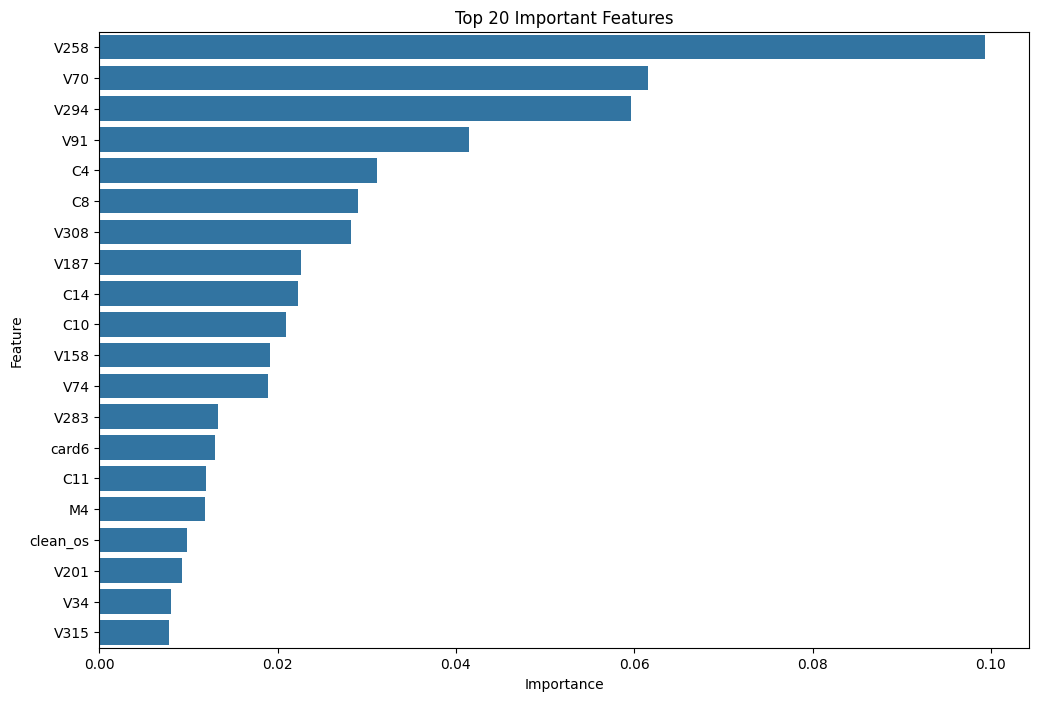

In [79]:
model = pipeline.named_steps['model']
feature_names = numeric_cols + categorical_cols
importance = model.feature_importances_
importance_df = pd.DataFrame({

    'Feature': feature_names,
    'Importance': importance

}).sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(20)
)
plt.title('Top 20 Important Features')
plt.show()

# Threshold Optimization

In [87]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.90, 100)
best_thresh = 0.5
best_score = -1

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    if rec >= 0.66:
        if f1 > best_score:
            best_score = f1
            best_thresh = t

print(f"\n[Success] Final Production Threshold Set to: {best_thresh:.4f}")


[Success] Final Production Threshold Set to: 0.6573


# Evaluation Reports

In [88]:
#Final Predictions
y_pred = (y_prob >= best_thresh).astype(int)

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Final Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")


--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     62932
           1       0.33      0.66      0.44      2203

    accuracy                           0.94     65135
   macro avg       0.66      0.81      0.71     65135
weighted avg       0.97      0.94      0.95     65135


--- Final Confusion Matrix ---
[[59958  2974]
 [  740  1463]]

ROC AUC Score: 0.9128


# Visualizations

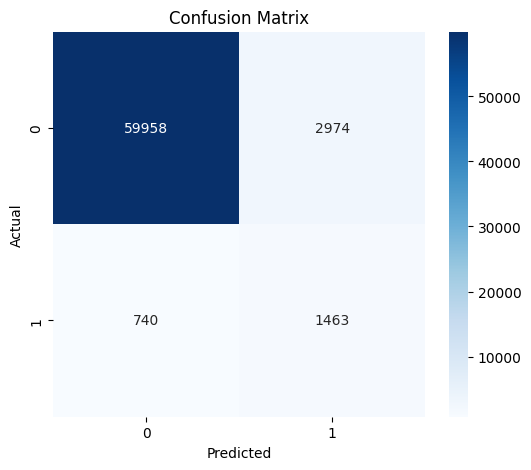

In [89]:
#Confusion Matrix Heatmap

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

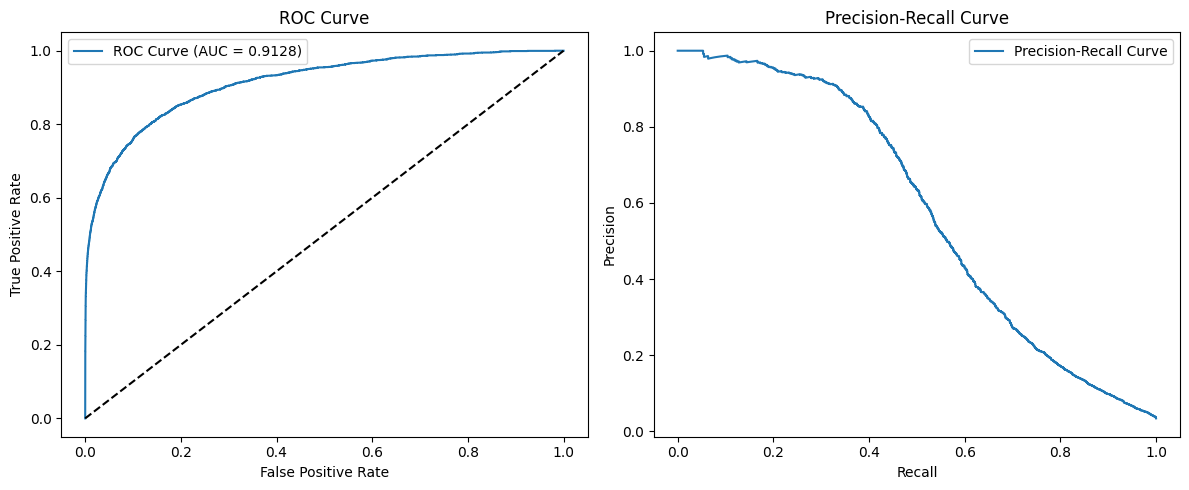

In [90]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretability & Dynamic System

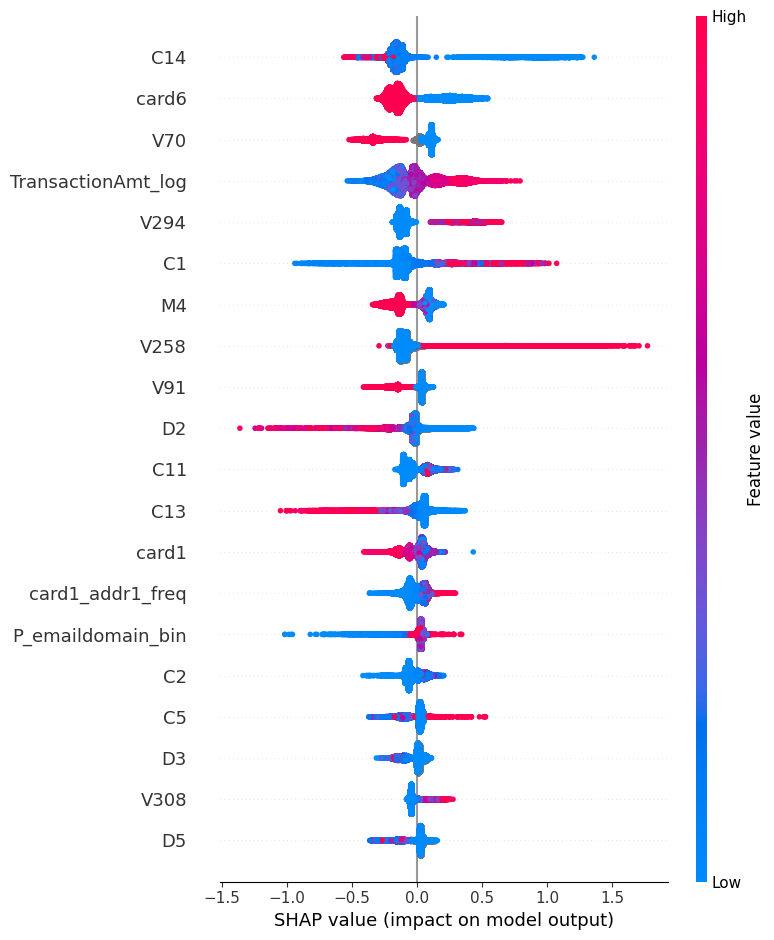

In [84]:
#### SHAP Explainability ####

X_test_preprocessed = pipeline.named_steps['prep'].transform(X_test)
model = pipeline.named_steps['model']

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_preprocessed)

plt.figure()
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=numeric_cols + categorical_cols)
plt.show()


In [85]:
#Save Model

joblib.dump(
    pipeline,
    'fraud_detection_pipeline.pkl'
)

print("\nPipeline Saved Successfully!")


Pipeline Saved Successfully!


# Interactive Fraud Detection System

In [91]:
print("Please enter the transaction details below to check for fraud risk:\n")

try:
    raw_amt = float(input("1. Enter Transaction Amount in USD (e.g., 5000 or 15): "))
    amt_log = np.log1p(raw_amt)

    hour = int(input("2. Enter Hour of the day (0 to 23): "))
    if not (0 <= hour <= 23): raise ValueError("Hour must be between 0 and 23.")

    is_night = int(input("3. Is it Night time? Enter 1 for Yes, 0 for No: "))
    if is_night not in [0, 1]: raise ValueError("Is_Night must be 0 or 1.")

    card_freq = int(input("4. Enter Card/Address Frequency (e.g., 1 for new, 150 for frequent): "))

    has_id_input = int(input("5. Does this transaction have Identity log? (1 for Yes, 0 for No): "))

    print("\nAvailable Options: [chrome, safari, firefox, samsung, other, Missing]")
    browser_input = input("6. Enter Browser type: ").strip().lower()

    print("Available Options: [windows, mac, ios, android, linux, other, Missing]")
    os_input = input("7. Enter OS type: ").strip().lower()

    user_case = X_test[y_test == 0].head(1).copy()

    user_case['TransactionAmt_log'] = amt_log
    user_case['Step_Hour'] = hour
    user_case['Is_Night'] = is_night
    user_case['has_identity'] = has_id_input

    if 'card1_addr1_freq' in user_case.columns:
        user_case['card1_addr1_freq'] = card_freq

    if 'clean_browser' in user_case.columns:
        user_case['clean_browser'] = browser_input

    if 'clean_os' in user_case.columns:
        user_case['clean_os'] = os_input

    prob = pipeline.predict_proba(user_case)[:, 1][0]
    # test_threshold = best_thresh
    pred = int(prob >= best_thresh)

    print("\n" + "="*50)
    print("                 DETECTION RESULT             ")
    print("="*50)
    print(f"Input Amount: ${raw_amt:,.2f}")
    print(f"Time of Transaction: {hour}:00 | Night Flag: {is_night}")
    print(f"Card Frequency: {card_freq} time(s) seen | Has Identity Log: {has_id_input}")
    print(f"Device Environment: Browser: {browser_input} | OS: {os_input}")
    print("-"*50)
    print(f"Calculated Fraud Probability: {prob * 100:.2f}%")

    if pred == 1:
        print("CRITICAL ALERT: High Risk of Fraud Detected! [Class 1]")
        print("Action Recommended: Hold transaction and trigger OTP verification.")
    else:
        print("STATUS: Low Risk Transaction. [Class 0]")
        print("Action Recommended: Approve transaction automatically.")
    print("="*50)

except ValueError as e:
    print(f"\n[Input Error]: Please enter valid data types. Details: {e}")

Please enter the transaction details below to check for fraud risk:

1. Enter Transaction Amount in USD (e.g., 5000 or 15): 12
2. Enter Hour of the day (0 to 23): 2
3. Is it Night time? Enter 1 for Yes, 0 for No: 1
4. Enter Card/Address Frequency (e.g., 1 for new, 150 for frequent): 1
5. Does this transaction have Identity log? (1 for Yes, 0 for No): 0

Available Options: [chrome, safari, firefox, samsung, other, Missing]
6. Enter Browser type: safari
Available Options: [windows, mac, ios, android, linux, other, Missing]
7. Enter OS type: linux

                 DETECTION RESULT             
Input Amount: $12.00
Time of Transaction: 2:00 | Night Flag: 1
Card Frequency: 1 time(s) seen | Has Identity Log: 0
Device Environment: Browser: safari | OS: linux
--------------------------------------------------
Calculated Fraud Probability: 55.13%
CRITICAL ALERT: High Risk of Fraud Detected! [Class 1]
Action Recommended: Hold transaction and trigger OTP verification.
